# Notebook 05C - BioBERT Fine-Tuning

## Environment Setup and Library Imports 

This section initialises the environment and imports all required libraries for fine-tuning and evaluating the BioBERT model on the clinical readmission prediction task.

The setup includes libraries for data handling, deep learning, visualisation, and evaluation. PyTorch is used for dataset preparation and tensor operations, while the Hugging Face *transformers* library provides the pre-trained BioBERT model, tokenizer, and training framework.

Scikit-learn utilities are included for dataset splitting, class imbalance handling, and computation of evaluation metrics such as ROC-AUC and Precision–Recall AUC. These metrics are particularly important for assessing performance in imbalanced clinical classification tasks.

Project-specific configuration parameters are imported centrally to ensure consistency across experiments, including file paths, model identifiers, hyperparameters, and output locations.

Finally, a dedicated directory is created for storing BioBERT visualisations, and global plotting settings are applied to maintain a consistent visual style across all generated figures. This structured setup ensures reproducibility and alignment with the previously implemented DistilBERT and PubMedBERT pipelines.

In [1]:
# System Path Configuration
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Core Data Handling Libraries
import pandas as pd
import numpy as np
import pickle

# PyTorch Utilities
import torch
from torch.utils.data import Dataset

# Visualisation and Warning Control
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Hugging Face Transformers Components
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

# Scikit-learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

# Evaluation Library
import evaluate

# Project Configuration Parameters
from config import (
    LABELLED_DATASET,
    BIOBERT_MODEL_ID,
    BIOBERT_DIR,
    BIOBERT_RESULTS_CSV,
    BIOBERT_PREDS_PKL,
    PLOTS_DIR,
    MAX_LENGTH,
    NUM_EPOCHS,
    BATCH_SIZE,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_STEPS,
    EARLY_STOPPING_PATIENCE,
    RANDOM_STATE,
    TEST_SIZE,
    VAL_SIZE,
    NUM_LABELS,
)


# Create BioBERT Plot Save Directory
BIOBERT_PLOTS_DIR = PLOTS_DIR / "biobert_model"
BIOBERT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

## Data Preparation and Experimental Setup 

This section prepares the dataset and experimental environment for fine-tuning the BioBERT model on the clinical readmission prediction task.

To ensure reproducibility, random seeds are fixed across all components of the pipeline. GPU acceleration is utilised when available, with mixed-precision (FP16) enabled to improve computational efficiency and reduce memory usage.

The labelled dataset is loaded and split into training, validation, and test sets using stratified sampling. This ensures that the class distribution is preserved across all splits, which is particularly important for imbalanced clinical datasets. The same random seed and splitting strategy as previous experiments are used to maintain consistency and enable fair comparison across baseline models, DistilBERT, and PubMedBERT.

Class imbalance is addressed by computing class weights using a balanced weighting scheme. These weights are later incorporated into the loss function to ensure that minority class instances (readmitted patients) are appropriately emphasised during training.

Finally, dataset statistics are reported to verify correct preprocessing and confirm that class distributions are consistent across splits.

In [2]:
# Reproducibility Setup
set_seed(RANDOM_STATE)

# cuDNN Configuration for Performance Optimisation
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Device Selection (GPU if available, else CPU)
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = (device.type == 'cuda')

# Dataset Loading
df = pd.read_csv(LABELLED_DATASET)

# Feature and Label Extraction
X = df['narrative'].to_numpy(dtype=str)
y = df['readmission_30d'].to_numpy(dtype=int)

# Train / Validation / Test Split (Stratified -- identical seed to 05a and 05b)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Class Weight Computation (Handling Imbalance)
cw_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

cw_dict = {
    0: float(cw_arr[0]),
    1: float(cw_arr[1])
}

# Dataset Summary Statistics
print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')
print(f'Train label dist : {np.bincount(y_train)}')
print(f'Class weights : {cw_dict}')

Train : 28,876  |  Val : 3,610  |  Test : 3,610
Train label dist : [23325  5551]
Class weights : {0: 0.6189924973204716, 1: 2.600972797694109}


## Case Sensitivity Analysis in BioBERT Tokenisation

This section demonstrates the importance of case sensitivity in clinical text processing using BioBERT.

Unlike uncased models, BioBERT uses a cased vocabulary, allowing it to distinguish between tokens that differ only by letter casing. In clinical narratives, such distinctions are often semantically meaningful. For example, uppercase abbreviations such as *ICU*, *HE*, and *K* represent specific medical concepts, whereas their lowercase counterparts may have entirely different meanings or no clinical significance.

A set of representative examples is evaluated to compare tokenisation outcomes between original and lowercased inputs. Differences in tokenisation indicate that the model preserves case-specific semantic information.

This behaviour is particularly valuable in clinical NLP tasks, where abbreviations, units, and symbols carry critical meaning. By retaining case information, BioBERT can better capture domain-specific nuances, leading to improved representation and potentially enhanced predictive performance.

In [3]:
# Tokeniser Loading
tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL_ID)

# Cased Vocabulary Demonstration
print('BioBERT cased tokenisation:\n')

cased_examples = [
    ('ICU stay',     'icu stay',     'ICU = intensive care unit'),
    ('Mg 2.1 meq/L', 'mg 2.1 meq/L', 'Mg = magnesium element'),
    ('HE grade 2',   'he grade 2',   'HE = hepatic encephalopathy'),
    ('K+ low',       'k+ low',       'K = potassium'),
    ('T 38.4',       't 38.4',       'T = temperature'),
]

print(f'{"Original":<20}  {"Lowercased":<20}  {"Tokens differ?"}')
print('-' * 65)

for orig, lower, note in cased_examples:
    t_orig  = tokenizer.tokenize(orig)
    t_lower = tokenizer.tokenize(lower)
    diff = f'YES  ({note})' if t_orig != t_lower else 'same'
    print(f'{orig:<20}  {lower:<20}  {diff}')

BioBERT cased tokenisation:

Original              Lowercased            Tokens differ?
-----------------------------------------------------------------
ICU stay              icu stay              YES  (ICU = intensive care unit)
Mg 2.1 meq/L          mg 2.1 meq/L          YES  (Mg = magnesium element)
HE grade 2            he grade 2            YES  (HE = hepatic encephalopathy)
K+ low                k+ low                YES  (K = potassium)
T 38.4                t 38.4                YES  (T = temperature)


## Tokenised Dataset Construction 

This section defines a custom PyTorch dataset for handling tokenised clinical narratives during BioBERT fine-tuning.

Each narrative is converted into token IDs using the BioBERT tokenizer, with truncation and padding applied to enforce a fixed sequence length. This ensures compatibility with transformer input requirements while maintaining uniform batch dimensions.

The dataset class encapsulates both tokenised inputs and corresponding labels, enabling efficient integration with the Hugging Face Trainer API. Each returned sample includes input IDs, attention masks, and labels in tensor format.

Separate dataset instances are created for training, validation, and test splits, ensuring proper separation of data throughout the experimental pipeline.

This modular dataset design improves code readability, reusability, and computational efficiency during model training and evaluation.

In [4]:
# Custom PyTorch Dataset for Tokenised Inputs
class ClinicalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        # Text Tokenisation (Padding + Truncation)
        self.enc = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        # Label Tensor Conversion
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        # Dataset Size
        return len(self.labels)

    def __getitem__(self, idx):
        # Retrieve Encoded Inputs and Corresponding Label
        item = {k: v[idx] for k, v in self.enc.items()}
        item['labels'] = self.labels[idx]
        return item

# Dataset Instantiation (Train / Validation / Test)
train_ds = ClinicalDataset(X_train, y_train, tokenizer)
val_ds   = ClinicalDataset(X_val,   y_val,   tokenizer)
test_ds  = ClinicalDataset(X_test,  y_test,  tokenizer)

# Confirmation Output
print(f'Datasets created  (max_length={MAX_LENGTH})')

Datasets created  (max_length=256)


## Class-Imbalance Handling and Evaluation Metrics

This section defines the training and evaluation strategy for BioBERT, with a focus on handling class imbalance and ensuring robust performance assessment.

To address imbalance in the readmission prediction task, a custom Trainer is implemented using class-weighted cross-entropy loss. This ensures that minority class instances (readmitted patients) are given higher importance during optimisation, improving recall and reducing bias toward the majority class.

The computed class weights are incorporated directly into the loss function and applied at each training step, enabling balanced learning across classes.

Model performance is evaluated using multiple complementary metrics. Accuracy provides an overall performance measure, while weighted F1-score accounts for class imbalance. ROC-AUC evaluates the model’s ability to rank positive instances correctly, and PR-AUC focuses on precision–recall trade-offs, which are particularly important in imbalanced clinical datasets.

Logits are converted into probabilities using softmax to enable computation of these threshold-independent metrics. Safe handling is included to prevent errors in edge cases where metric computation may fail.

This evaluation framework ensures that BioBERT is assessed rigorously and consistently with other models in the study.

In [5]:
# Custom Trainer with Class-Weighted Loss
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Class Weight Tensor 
        w = torch.tensor(
            [class_weights[0], class_weights[1]],
            dtype=torch.float
        ).to(device)

        # Weighted Cross-Entropy Loss
        self.loss_fn = torch.nn.CrossEntropyLoss(weight=w)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extract Labels and Forward Pass
        labels  = inputs.pop('labels')
        outputs = model(**inputs)

        # Compute Weighted Loss
        loss = self.loss_fn(outputs.logits, labels)

        return (loss, outputs) if return_outputs else loss


# Accuracy Metric Initialisation
acc_metric = evaluate.load('accuracy')


# Evaluation Metrics Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Predictions and Probabilities
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(
        torch.tensor(logits, dtype=torch.float32),
        dim=-1
    ).numpy()[:, 1]

    # Accuracy Computation
    acc = acc_metric.compute(
        predictions=preds,
        references=labels
    )['accuracy']

    # Classification Report (Weighted F1)
    rep = classification_report(
        labels,
        preds,
        output_dict=True,
        zero_division=0
    )

    # ROC-AUC and PR-AUC 
    try:
        roc = roc_auc_score(labels, probs)
        pr  = average_precision_score(labels, probs)
    except ValueError:
        roc = pr = 0.0

    # Metric Dictionary
    return {
        'accuracy'    : acc,
        'f1_weighted' : rep['weighted avg']['f1-score'],
        'roc_auc'     : roc,
        'pr_auc'      : pr,
    }

## Model Initialisation and Configuration 

This section initialises the BioBERT model for sequence classification and prepares it for fine-tuning on the readmission prediction task.

BioBERT is a domain-adapted transformer model, originally based on BERT and further pre-trained on large-scale biomedical corpora. Its architecture is well-suited for capturing complex clinical semantics, particularly in case-sensitive contexts.

The model is loaded with a sequence classification head configured for binary classification. The number of output labels is specified to align with the readmission prediction task.

Following initialisation, the model is moved to the selected computational device (GPU or CPU). The total and trainable parameter counts are computed to provide insight into model capacity and computational complexity.

This step ensures that the model is correctly configured and ready for fine-tuning within the training pipeline.

In [6]:
# Model Initialisation 
model = AutoModelForSequenceClassification.from_pretrained(
    BIOBERT_MODEL_ID,
    num_labels=NUM_LABELS
)

# Move Model to Device
model.to(device)

# Parameter Count 
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Parameters  : {total_p:,} total  |  {trainable_p:,} trainable')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1315.16it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes

Parameters  : 108,311,810 total  |  108,311,810 trainable


## Training Configuration and Fine-Tuning Strategy 

This section defines the training configuration and executes fine-tuning of the BioBERT model.

Training hyperparameters, including learning rate, batch size, number of epochs, weight decay, and warmup steps, are specified using the Hugging Face TrainingArguments interface. A warmup strategy is applied to stabilise training in the initial phases and prevent large gradient updates.

Model evaluation is performed at the end of each epoch, and checkpoints are saved periodically. The best-performing model is selected based on validation ROC-AUC, ensuring that model selection is aligned with performance under class imbalance.

Mixed-precision training (FP16) is enabled when using a GPU to improve computational efficiency and reduce memory usage. Early stopping is incorporated to prevent overfitting by halting training when validation performance no longer improves.

The custom WeightedTrainer is used to incorporate class-weighted loss, ensuring balanced optimisation across classes.

Finally, the model is trained, and total runtime is reported to provide insight into computational cost.

In [7]:
# Training Arguments Configuration
training_args = TrainingArguments(
    output_dir = BIOBERT_DIR,
    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE * 2,
    learning_rate = LEARNING_RATE,
    warmup_steps = WARMUP_STEPS,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'roc_auc',
    greater_is_better = True,
    fp16 = USE_FP16,
    dataloader_pin_memory = (device.type == 'cuda'),
    dataloader_num_workers = 0,
    logging_steps = 50,
    report_to = 'none',
    seed = RANDOM_STATE,
)

# Trainer Initialisation
trainer = WeightedTrainer(
    class_weights = cw_dict,
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_metrics,
    callbacks = [
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE
        )
    ],
)

# Training Start Notification
print('Starting BioBERT fine-tuning...')

# Model Training Execution
train_result = trainer.train()

# Training Runtime Summary
runtime_min = train_result.metrics['train_runtime'] / 60
print(f'Training complete in {runtime_min:.1f} min')

Starting BioBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Roc Auc,Pr Auc
1,0.705654,0.688707,0.811634,0.732485,0.668298,0.338734
2,0.658884,0.631430,0.616620,0.657234,0.704403,0.359458
3,0.697888,0.692083,0.801385,0.746740,0.628479,0.297062
4,0.638255,0.646630,0.731025,0.746097,0.702562,0.391660
5,0.644318,0.656936,0.507202,0.551528,0.664518,0.353898


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.49it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training complete in 22.4 min


## Training Dynamics and Convergence Analysis

This section analyses the training behaviour of the BioBERT model using logged metrics collected during fine-tuning. Monitoring training dynamics is essential for understanding model convergence, stability, and potential overfitting.

Training loss is plotted against optimisation steps to assess how effectively the model minimises the objective function over time. A smooth and decreasing loss curve typically indicates stable learning.

Validation performance is evaluated across epochs using ROC-AUC and weighted F1-score. These metrics provide insight into generalisation performance and help identify the point at which the model achieves optimal validation performance.

By jointly analysing training loss and validation metrics, it becomes possible to diagnose issues such as overfitting or underfitting. This analysis also supports interpretation of the early stopping and model selection strategy used during fine-tuning.

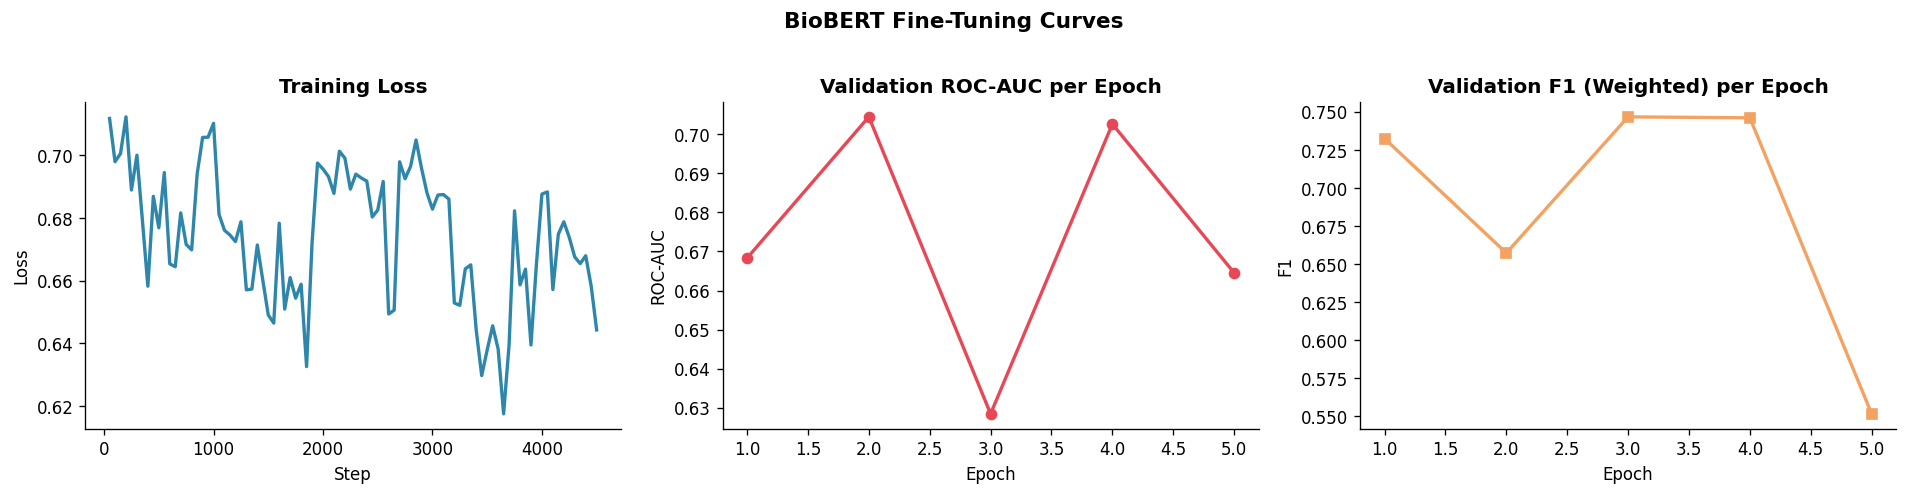

In [8]:
# Extract Training and Evaluation Logs
log_history = trainer.state.log_history

train_logs = [
    x for x in log_history
    if 'loss' in x and 'eval_loss' not in x
]

eval_logs = [
    x for x in log_history
    if 'eval_loss' in x
]

# Plot Training Curves (If Logs Available)
if train_logs and eval_logs:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Training Loss vs Steps
    axes[0].plot(
        [x['step'] for x in train_logs],
        [x['loss'] for x in train_logs],
        color=PALETTE[0],
        lw=2
    )
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

    # Validation ROC-AUC per Epoch
    axes[1].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_roc_auc', 0) for x in eval_logs],
        'o-',
        color=PALETTE[1],
        lw=2,
        markersize=6
    )
    axes[1].set_title('Validation ROC-AUC per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('ROC-AUC')

    # Validation Weighted F1 per Epoch
    axes[2].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_f1_weighted', 0) for x in eval_logs],
        's-',
        color=PALETTE[2],
        lw=2,
        markersize=6
    )
    axes[2].set_title('Validation F1 (Weighted) per Epoch', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1')

    # Figure Formatting and Save
    plt.suptitle(
        'BioBERT Fine-Tuning Curves',
        fontsize=13,
        fontweight='bold',
        y=1.02
    )
    plt.tight_layout()

    plt.savefig(
        f'{BIOBERT_PLOTS_DIR}/bio_01_training_curves.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

## Test Set Evaluation and Performance Analysis

This section evaluates the fine-tuned BioBERT model on the held-out test set, providing a comprehensive assessment of its generalisation performance. Evaluation on unseen data is essential for determining how well the model transfers beyond the training and validation sets.

Predictions are generated for the test dataset, and class probabilities are obtained from the model logits using the softmax function. These probabilities are then used to compute threshold-independent evaluation metrics, including ROC-AUC and Precision–Recall AUC, which are particularly informative for imbalanced classification tasks.

A detailed classification report is produced to summarise precision, recall, and F1-score for each class. In addition, ROC and Precision–Recall curves are plotted to illustrate model performance across different decision thresholds, while the confusion matrix provides a direct view of correct and incorrect predictions.

Together, these outputs provide a robust and interpretable summary of BioBERT’s predictive performance. They also enable direct comparison with the baseline and other transformer models used in the study.


 BioBERT - Test Set Results 
                precision    recall  f1-score   support

Not Readmitted       0.89      0.58      0.70      2916
    Readmitted       0.28      0.69      0.40       694

      accuracy                           0.60      3610
     macro avg       0.58      0.63      0.55      3610
  weighted avg       0.77      0.60      0.64      3610

ROC-AUC : 0.6831   PR-AUC : 0.3305


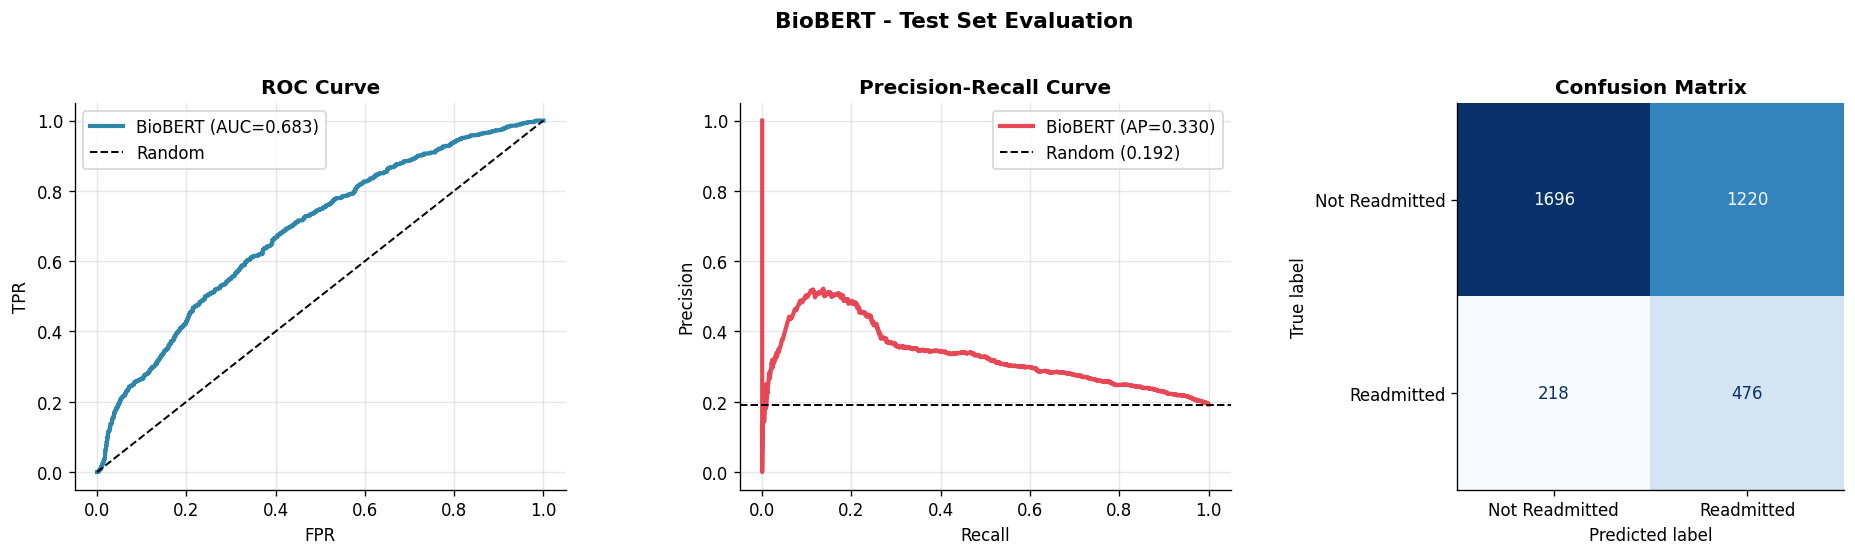

In [9]:
# Test Set Prediction
pred_out = trainer.predict(test_ds)

# Logits, Predicted Labels, and Probabilities
logits = pred_out.predictions
y_pred = np.argmax(logits, axis=-1)

y_prob = torch.softmax(
    torch.tensor(logits, dtype=torch.float32),
    dim=-1
).numpy()[:, 1]

# Evaluation Metrics (Test Set)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Results Output
print('\n BioBERT - Test Set Results ')
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Readmitted', 'Readmitted'],
    zero_division=0
))
print(f'ROC-AUC : {roc_auc:.4f}   PR-AUC : {pr_auc:.4f}')

# Curve Computation (ROC and Precision-Recall)
fpr, tpr, _  = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)

# Plot Evaluation Metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC Curve
axes[0].plot(
    fpr, tpr,
    color=PALETTE[0],
    lw=2.5,
    label=f'BioBERT (AUC={roc_auc:.3f})'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(
    rec, prec,
    color=PALETTE[1],
    lw=2.5,
    label=f'BioBERT (AP={pr_auc:.3f})'
)
axes[1].axhline(
    y=y_test.mean(),
    color='k',
    linestyle='--',
    lw=1.2,
    label=f'Random ({y_test.mean():.3f})'
)
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not Readmitted', 'Readmitted']
).plot(ax=axes[2], colorbar=False, cmap='Blues')

axes[2].set_title('Confusion Matrix', fontweight='bold')

# Figure Formatting and Save
plt.suptitle(
    'BioBERT - Test Set Evaluation',
    fontsize=13,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()

plt.savefig(
    f'{BIOBERT_PLOTS_DIR}/bio_02_test_evaluation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Prediction Confidence and Error Analysis

This section analyses the confidence of BioBERT’s predictions by examining the distribution of predicted probabilities. Understanding prediction confidence provides deeper insight into model behaviour beyond standard evaluation metrics.

The distribution of probabilities is first analysed with respect to the true labels, allowing assessment of how well the model separates the two classes. Ideally, predictions for each class should be concentrated at opposite ends of the probability spectrum, indicating strong class discrimination.

Confidence is also analysed based on prediction correctness, comparing correctly classified and misclassified instances. This helps identify whether incorrect predictions are associated with low confidence (uncertainty) or high confidence (overconfidence), which has important implications for model reliability.

A fixed decision threshold of 0.5 is used to map probabilities to class labels, and its position is visualised in both plots. This analysis supports interpretation of model calibration and highlights potential areas for improvement, such as threshold tuning or probability calibration.

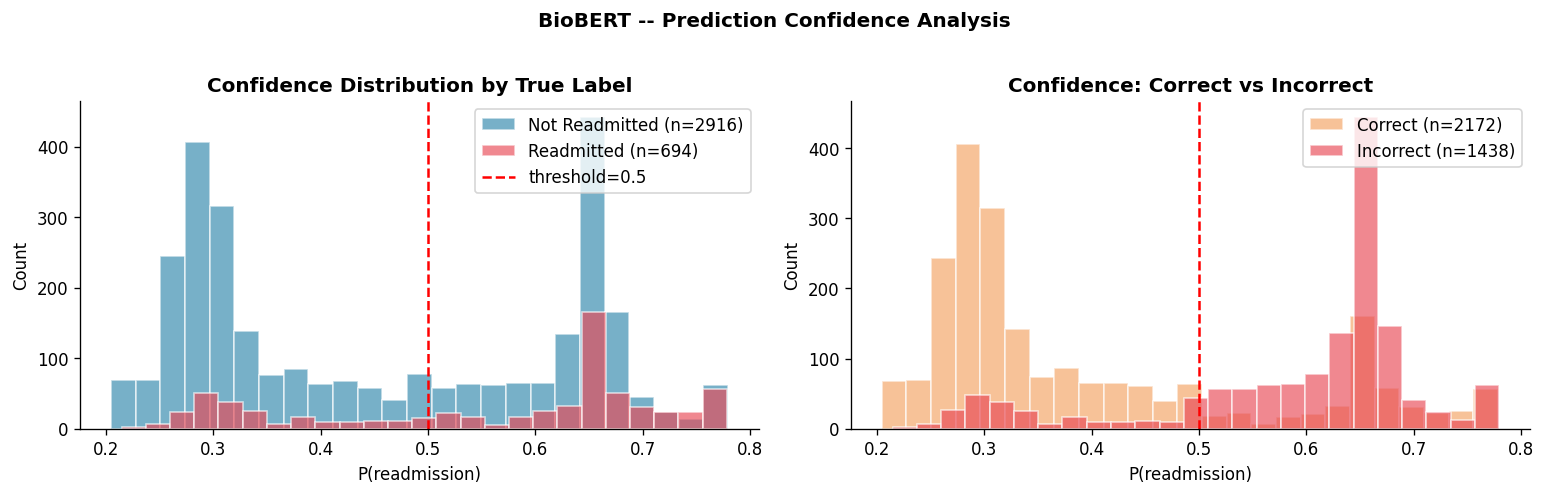

In [10]:
# Confidence Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence by True Label
for label, color, name in [
    (0, PALETTE[0], 'Not Readmitted'),
    (1, PALETTE[1], 'Readmitted')
]:
    sub = y_prob[y_test == label]

    axes[0].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{name} (n={len(sub)})'
    )

# Decision Threshold Line
axes[0].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5,
    label='threshold=0.5'
)

axes[0].set_title('Confidence Distribution by True Label', fontweight='bold')
axes[0].set_xlabel('P(readmission)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Confidence by Prediction Correctness
correct = (y_pred == y_test)

for flag, color, lbl in [
    (True,  PALETTE[2], 'Correct'),
    (False, PALETTE[1], 'Incorrect')
]:
    sub = y_prob[correct == flag]

    axes[1].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{lbl} (n={len(sub)})'
    )

# Decision Threshold Line
axes[1].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5
)

axes[1].set_title('Confidence: Correct vs Incorrect', fontweight='bold')
axes[1].set_xlabel('P(readmission)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Figure Formatting and Save
plt.suptitle(
    'BioBERT -- Prediction Confidence Analysis',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{BIOBERT_PLOTS_DIR}/bio_03_confidence_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Saving Evaluation Results and Artifacts

This section stores the evaluation results of the BioBERT model for reproducibility and downstream analysis. Persisting results ensures that experiments can be reliably compared and revisited without re-running the full training pipeline.

Key performance metrics, including accuracy, precision, recall, F1-scores, ROC-AUC, and PR-AUC, are saved to a structured CSV file. This enables systematic comparison across different models and configurations used in the study.

In addition, detailed prediction outputs and evaluation artifacts are stored using a serialized pickle file. These include predicted labels, probabilities, confusion matrix components, and curve data required for further analysis or visualisation.

Saving both summary metrics and detailed outputs supports transparency, reproducibility, and efficient integration of results into the final report and comparative evaluation.

In [11]:
# Save Evaluation Metrics to CSV
pd.DataFrame([{
    'Model' : 'BioBERT',
    'Model_ID' : BIOBERT_MODEL_ID,
    'Type' : 'Transformer',
    'Domain' : 'Biomedical (BERT-base-cased + continued pretraining on PubMed + PMC)',
    'Accuracy' : report['accuracy'],
    'Precision_Pos' : report['1']['precision'],
    'Recall_Pos' : report['1']['recall'],
    'F1_Pos' : report['1']['f1-score'],
    'F1_Weighted' : report['weighted avg']['f1-score'],
    'ROC_AUC' : roc_auc,
    'PR_AUC' : pr_auc,
}]).to_csv(
    BIOBERT_RESULTS_CSV,
    index=False
)

# Save Predictions and Evaluation Artifacts 
with open(BIOBERT_PREDS_PKL, 'wb') as f:
    pickle.dump({
        'y_test' : y_test,
        'y_pred' : y_pred,
        'y_prob' : y_prob,
        'X_test' : X_test,
        'report' : report,
        'roc_auc' : roc_auc,
        'pr_auc' : pr_auc,
        'fpr' : fpr,
        'tpr' : tpr,
        'prec' : prec,
        'rec' : rec,
    }, f)

# Final Metric Summary
print(f'\nROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')


ROC-AUC : 0.6831  |  PR-AUC : 0.3305
